In [13]:
# CELL 1: Imports
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, Input,
                                     LSTM, concatenate, Flatten)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC

import warnings
warnings.filterwarnings('ignore')

In [14]:
# CELL 2: Load Processed Data
print("=" * 60)
print("LOADING PROCESSED DATA")
print("=" * 60)

# Static data
X_static_train = joblib.load("../models/X_static_train.pkl")
X_static_test = joblib.load("../models/X_static_test.pkl")

# LSTM data
X_lstm_train = joblib.load("../models/X_lstm_train.pkl")
X_lstm_test = joblib.load("../models/X_lstm_test.pkl")

# Target
y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

print("✅ All data loaded successfully!")
print(f"\n📊 Dataset Shapes:")
print(f"   Static Train: {X_static_train.shape}")
print(f"   LSTM Train:   {X_lstm_train.shape}")
print(f"   Target Train: {len(y_train)}")
print(f"   Static Test:  {X_static_test.shape}")
print(f"   LSTM Test:    {X_lstm_test.shape}")
print(f"   Target Test:  {len(y_test)}")

LOADING PROCESSED DATA
✅ All data loaded successfully!

📊 Dataset Shapes:
   Static Train: (12740, 16)
   LSTM Train:   (12740, 6, 1)
   Target Train: 12740
   Static Test:  (2000, 16)
   LSTM Test:    (2000, 6, 1)
   Target Test:  2000


In [15]:
# CELL 3: Build ANN Model (Static Data Branch)
#ANN Branch is used to train static datas like age groups, product count etc.
print("\n" + "=" * 60)
print("BUILDING ANN BRANCH (STATIC DATA)")
print("=" * 60)

def build_ann_branch(input_shape):
    """
    ANN branch for processing static customer features.
    Architecture:
    - 3 hidden layers with decreasing units
    - BatchNormalization for training stability
    - Dropout for regularization
    """
    inputs = Input(shape=input_shape, name='static_input')
    
    x = Dense(128, activation='relu')(inputs) # Find basic patterns
    x = BatchNormalization()(x) # Keeps training stable
    x = Dropout(0.3)(x)  # dropout 0.3, randomly pause 30% of nurones during training to prevent memorization
    
    x = Dense(64, activation='relu')(x) # find out the combinations i.e, old + high balance, young + few products etc
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    x = Dense(32, activation='relu')(x) # Summarize : creates final customer profile
    x = BatchNormalization()(x)
    
    return Model(inputs=inputs, outputs=x, name='ANN_Branch')

ann_branch = build_ann_branch(X_static_train.shape[1:])
ann_branch.summary()



BUILDING ANN BRANCH (STATIC DATA)


Model: "ANN_Branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ static_input (InputLayer)            │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,408 (52.38 KB)

 Trainable params: 12,960 (50.62 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
# CELL 4: Build LSTM Model (Temporal Data Branch)
# LSTM is used to train temporal data. Temporal data is that changes over time.
print("\n" + "=" * 60)
print("BUILDING LSTM BRANCH (TEMPORAL DATA)")
print("=" * 60)

def build_lstm_branch(input_shape):
    """
    LSTM branch for processing sequential balance data.
    Architecture:
    - Two LSTM layers to capture temporal patterns
    - Dropout for regularization
    """
    inputs = Input(shape=input_shape, name='lstm_input')
    
    # First LSTM layer returns sequences for the second LSTM, capture short term patterns
    x = LSTM(64, return_sequences=True, name='lstm_1')(inputs)
    x = Dropout(0.3)(x)
    
    # Second LSTM layer returns the final hidden state, captures long term patterns. Gives a compressed summary of 6 month balance story
    x = LSTM(32, return_sequences=False, name='lstm_2')(x)
    x = Dropout(0.3)(x)
    
    return Model(inputs=inputs, outputs=x, name='LSTM_Branch')

lstm_branch = build_lstm_branch(X_lstm_train.shape[1:])
lstm_branch.summary()


BUILDING LSTM BRANCH (TEMPORAL DATA)


Model: "LSTM_Branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)              │ (None, 6, 1)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 6, 64)               │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 32)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,312 (114.50 KB)

 Trainable params: 29,312 (114.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# CELL 5: Build Fusion Model
print("\n" + "=" * 60)
print("BUILDING MULTIMODAL FUSION MODEL")
print("=" * 60)

def build_multimodal_model(ann_branch, lstm_branch):
    """
    Combines ANN and LSTM branches with a fusion layer.
    """
    # Get outputs from both branches
    ann_output = ann_branch.output
    lstm_output = lstm_branch.output
    
    # Concatenate features from both branches
    combined = concatenate([ann_output, lstm_output], name='fusion')
    
    # Final classification layers
    x = Dense(32, activation='relu', name='dense_fusion_1')(combined)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu', name='dense_fusion_2')(x)
    output = Dense(1, activation='sigmoid', name='output')(x)
    
    # Create model with two inputs
    model = Model(
        inputs=[ann_branch.input, lstm_branch.input],
        outputs=output,
        name='Multimodal_Churn_Model'
    )
    
    return model

model = build_multimodal_model(ann_branch, lstm_branch)
model.summary()





BUILDING MULTIMODAL FUSION MODEL


Model: "Multimodal_Churn_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ static_input (InputLayer)     │ (None, 16)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 128)               │           2,176 │ static_input[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 128)               │             512 │ dense_3[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 128)               │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │           8,256 │ dropout_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_input (InputLayer)       │ (None, 6, 1)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 64)                │             256 │ dense_4[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 6, 64)             │          16,896 │ lstm_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_7 (Dropout)           │ (None, 64)                │               0 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_8 (Dropout)           │ (None, 6, 64)             │               0 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 32)                │           2,080 │ dropout_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 32)                │          12,416 │ dropout_8[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 32)                │             128 │ dense_5[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_9 (Dropout)           │ (None, 32)                │               0 │ lstm_2[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fusion (Concatenate)          │ (None, 64)                │               0 │ batch_normalization_5[0][… │
│                               │                           │                 │ dropout_9[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 45,345 (177.13 KB)

 Trainable params: 44,897 (175.38 KB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
# CELL 6: Compile Model
print("\n" + "=" * 60)
print("COMPILING MODEL")
print("=" * 60)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy', # Measures how wrong are we
    metrics=['accuracy', AUC(name='auc')]
)

print("✅ Model compiled successfully")



COMPILING MODEL
✅ Model compiled successfully


In [19]:
# CELL 7: Define Callbacks
# It monitor the model during training and make automatic decisions to improve results.  
print("\n" + "=" * 60)
print("SETUP CALLBACKS")
print("=" * 60)

callbacks = [
    # Stop training when the model stops improving, to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=15,   # Wait until 15 epochs before stop
        restore_best_weights=True,
        verbose=1
    ),
    # cut the learning rate
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5, # wait 5 epochs before reducing
        min_lr=0.00001,
        verbose=1
    )
]

print("✅ Callbacks configured:")
print("   - EarlyStopping: patience=15")
print("   - ReduceLROnPlateau: factor=0.5, patience=5")



SETUP CALLBACKS
✅ Callbacks configured:
   - EarlyStopping: patience=15
   - ReduceLROnPlateau: factor=0.5, patience=5


In [20]:
# CELL 8: Train Model
print("\n" + "=" * 60)
print("TRAINING MULTIMODAL MODEL")
print("=" * 60)

history = model.fit(
    [X_static_train, X_lstm_train],
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Model training complete!")


TRAINING MULTIMODAL MODEL
Epoch 1/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.6970 - auc: 0.7329 - loss: 0.5796 - val_accuracy: 0.6801 - val_auc: 0.0000e+00 - val_loss: 0.6246 - learning_rate: 0.0010
Epoch 2/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7627 - auc: 0.8178 - loss: 0.5027 - val_accuracy: 0.6621 - val_auc: 0.0000e+00 - val_loss: 0.5801 - learning_rate: 0.0010
Epoch 3/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7745 - auc: 0.8379 - loss: 0.4764 - val_accuracy: 0.6962 - val_auc: 0.0000e+00 - val_loss: 0.5698 - learning_rate: 0.0010
Epoch 4/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7815 - auc: 0.8557 - loss: 0.4535 - val_accuracy: 0.7312 - val_auc: 0.0000e+00 - val_loss: 0.5258 - learning_rate: 0.0010
Epoch 5/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7929 - auc: 0.8620 - loss: 0.4435 - val_accuracy: 0.6990 - val_auc: 0.0000e+00 - val_loss: 0.5531 - learning_rate: 0.0010
Epoch 6/100
319/319 ━━


PLOTTING TRAINING HISTORY


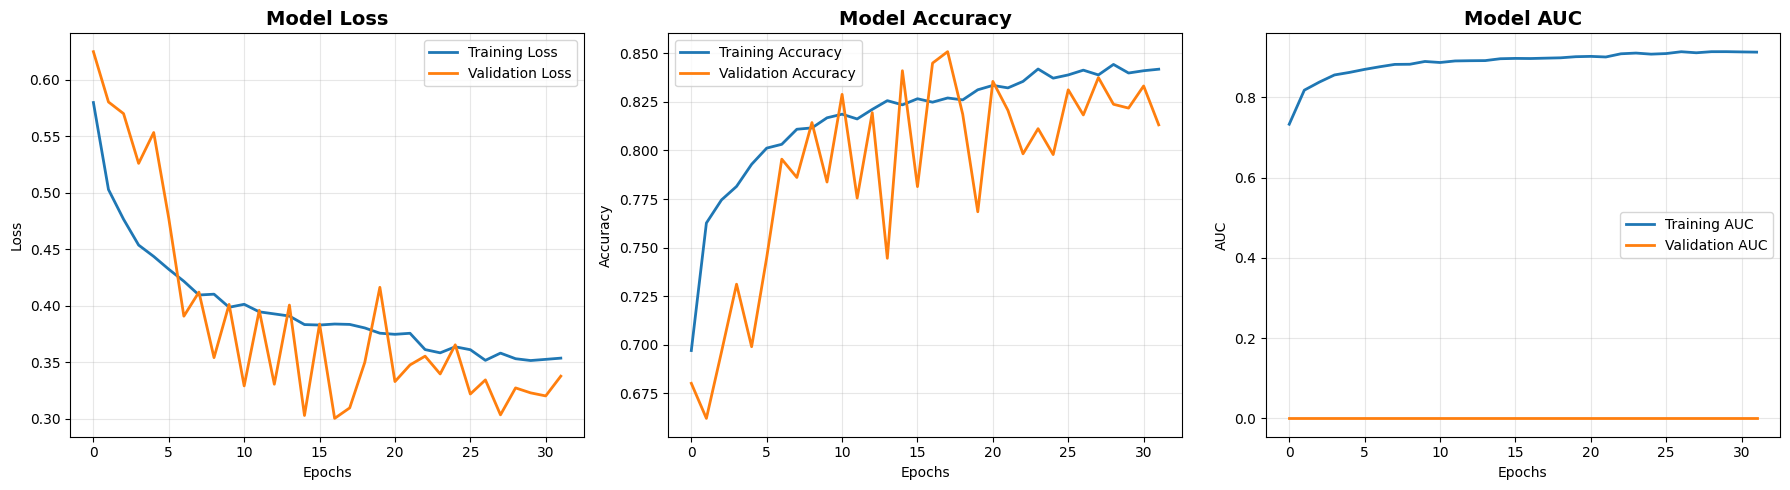

In [21]:
# CELL 9: Plot Training History
print("\n" + "=" * 60)
print("PLOTTING TRAINING HISTORY")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC plot
axes[2].plot(history.history['auc'], label='Training AUC', linewidth=2)
axes[2].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
axes[2].set_title('Model AUC', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# CELL 10: Evaluate on Test Set
print("\n" + "=" * 60)
print("EVALUATING ON TEST SET")
print("=" * 60)

# Get predictions
y_pred_prob = model.predict([X_static_test, X_lstm_test]).flatten()

# Find optimal threshold
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.02)
f1_scores = []

for threshold in thresholds:
    y_pred_temp = (y_pred_prob > threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_temp))

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"\n🎯 Optimal Threshold (based on F1): {optimal_threshold:.2f}")

# Make predictions with optimal threshold
y_pred = (y_pred_prob > optimal_threshold).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print("\n📊 TEST SET PERFORMANCE:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n📊 Confusion Matrix:")
print(cm)

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, 
                           target_names=['Not Churned', 'Churned']))


EVALUATING ON TEST SET
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

🎯 Optimal Threshold (based on F1): 0.54

📊 TEST SET PERFORMANCE:
   Accuracy:  0.8455
   Precision: 0.6237
   Recall:    0.6069
   F1-Score:  0.6152
   ROC-AUC:   0.8540

📊 Confusion Matrix:
[[1444  149]
 [ 160  247]]

📊 Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.90      0.91      0.90      1593
     Churned       0.62      0.61      0.62       407

    accuracy                           0.85      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.84      0.85      0.84      2000



Optimal Threshold: 0.54
What it means: Classify customers as "will churn" if their predicted probability is greater than 54%.


VISUALIZING PREDICTIONS


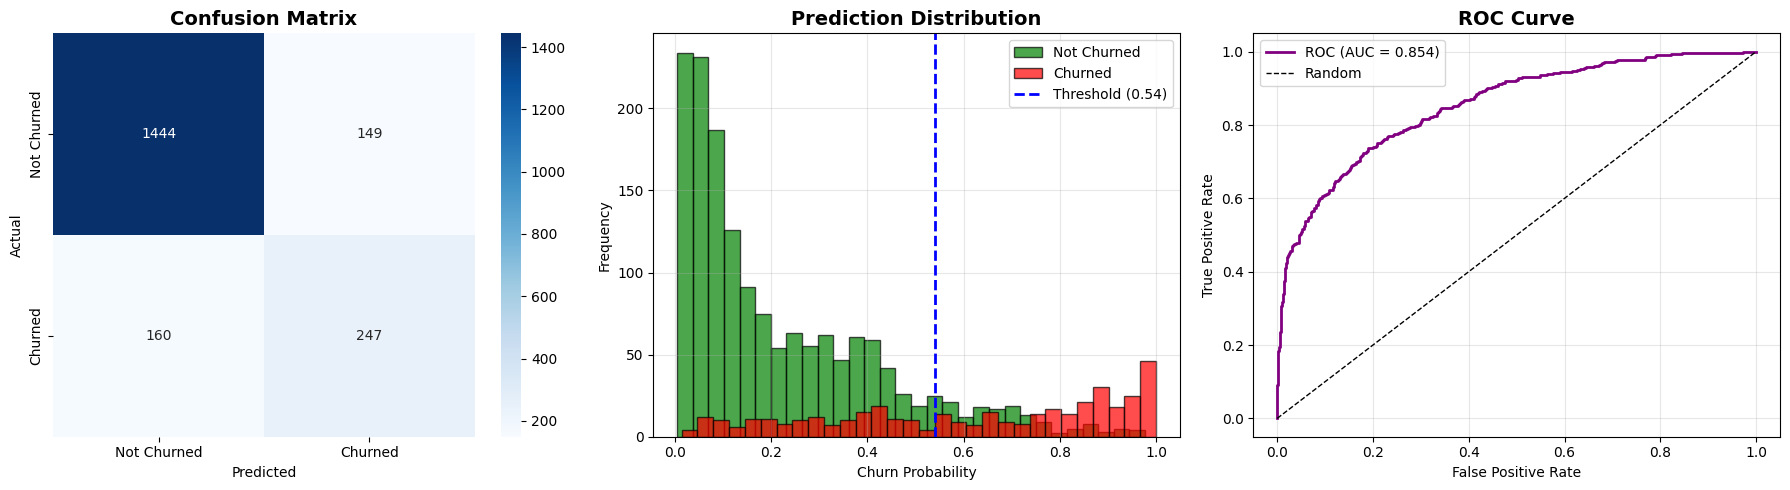

In [23]:
# CELL 11: Visualize Predictions
print("\n" + "=" * 60)
print("VISUALIZING PREDICTIONS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Probability Distribution
axes[1].hist(y_pred_prob[y_test == 0], bins=30, alpha=0.7, 
             label='Not Churned', color='green', edgecolor='black')
axes[1].hist(y_pred_prob[y_test == 1], bins=30, alpha=0.7,
             label='Churned', color='red', edgecolor='black')
axes[1].axvline(x=optimal_threshold, color='blue', linestyle='--', 
                linewidth=2, label=f'Threshold ({optimal_threshold:.2f})')
axes[1].set_title('Prediction Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

axes[2].plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {auc:.3f})', color='purple')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[2].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# CELL 12: Save Model and Threshold
print("\n" + "=" * 60)
print("SAVING MODEL AND ARTIFACTS")
print("=" * 60)

# Save the model
model.save("../models/multimodal_churn_model.keras")
print("✅ Model saved: ../models/multimodal_churn_model.keras")

# Save threshold
joblib.dump(optimal_threshold, "../models/optimal_threshold.pkl")
print("✅ Threshold saved: ../models/optimal_threshold.pkl")

# Save history
history_df = pd.DataFrame(history.history)
history_df.to_csv("../models/training_history.csv", index=False)
print("✅ Training history saved: ../models/training_history.csv")

# Save test predictions for later use
test_predictions_df = pd.DataFrame({
    'actual': y_test,
    'predicted_probability': y_pred_prob,
    'predicted': y_pred
})
test_predictions_df.to_csv("../models/test_predictions.csv", index=False)
print("✅ Test predictions saved: ../models/test_predictions.csv")

print("\n✅ All model artifacts saved successfully!")


SAVING MODEL AND ARTIFACTS
✅ Model saved: ../models/multimodal_churn_model.keras
✅ Threshold saved: ../models/optimal_threshold.pkl
✅ Training history saved: ../models/training_history.csv
✅ Test predictions saved: ../models/test_predictions.csv

✅ All model artifacts saved successfully!
